[*********************100%***********************]  1 of 1 completed

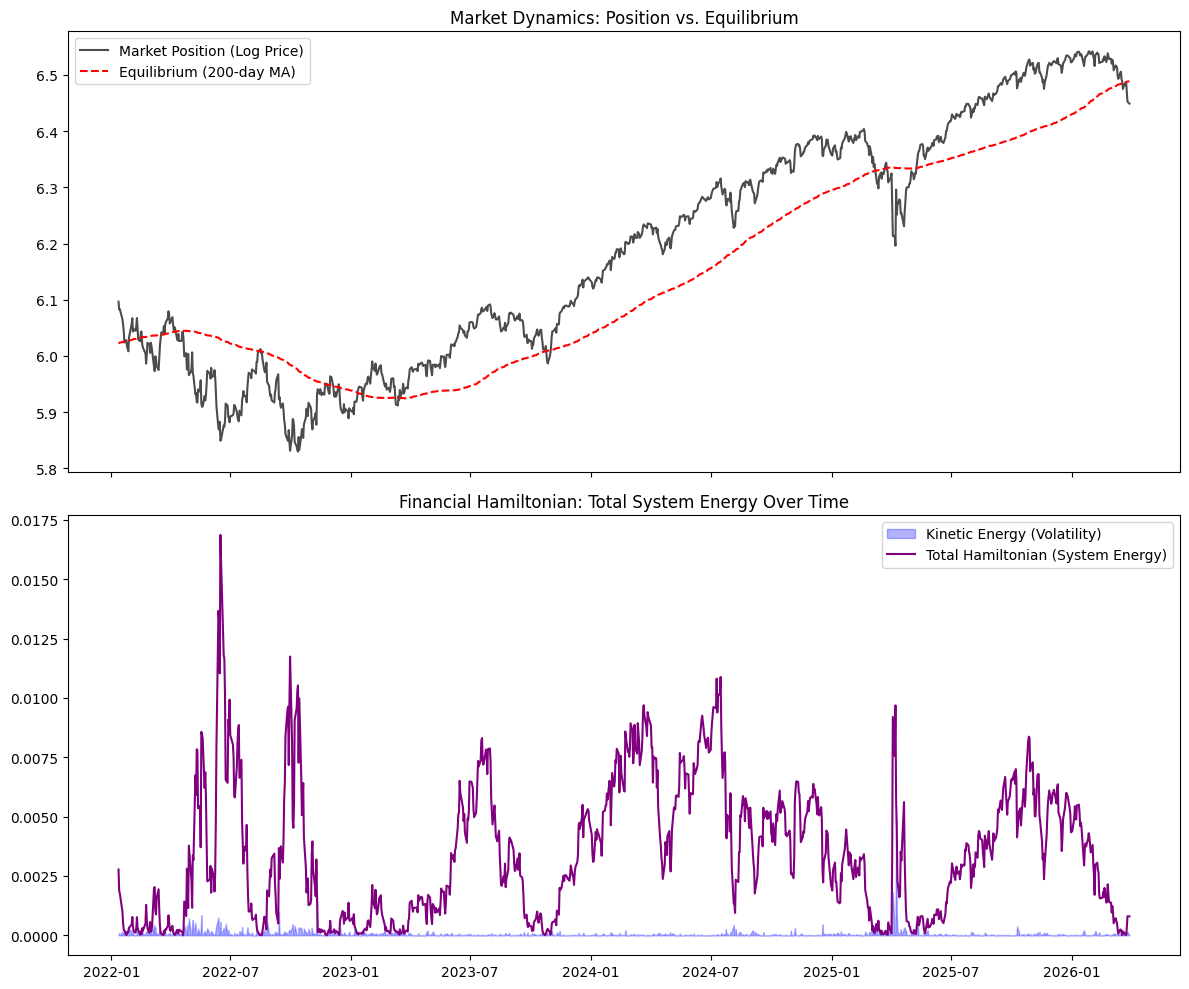

In [15]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def generate_financial_hamiltonian(ticker="SPY", period="5y"):
    # 1. Download Data
    print(f"Downloading data for {ticker}...")
    df = yf.download(ticker, period=period)
    
    # Use adjusted close for accurate returns
    price = df['Close']
    
    # 2. Position (q) and Velocity (v)
    # We define 'Position' as log-prices for better statistical properties
    df['q'] = np.log(price)
    
    # 'Velocity' is the rate of change (returns)
    df['v'] = df['q'].diff()
    
    # 3. Define the 'Restoring Force' (Potential Energy V)
    # The 200-day Moving Average represents the system's 'Equilibrium'
    df['MA200'] = df['q'].rolling(window=200).mean()
    
    # V = 0.5 * k * x^2 (Spring Potential) 
    # where x is the displacement from the moving average
    df['displacement'] = df['q'] - df['MA200']
    df['Potential_Energy'] = 0.5 * (df['displacement']**2)
    
    # 4. Define 'Kinetic Energy' (K)
    # K = 0.5 * m * v^2 (where mass m is assumed to be 1)
    df['Kinetic_Energy'] = 0.5 * (df['v']**2)
    
    # 5. The Hamiltonian (H)
    # H = K + V (Total Energy of the Market System)
    df['Hamiltonian'] = df['Kinetic_Energy'] + df['Potential_Energy']
    
    return df.dropna()

# Execute and Visualize
data = generate_financial_hamiltonian()

# Plotting the Energy States
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

ax1.plot(data.index, data['q'], label='Market Position (Log Price)', color='black', alpha=0.7)
ax1.plot(data.index, data['MA200'], label='Equilibrium (200-day MA)', color='red', linestyle='--')
ax1.set_title("Market Dynamics: Position vs. Equilibrium")
ax1.legend()

ax2.fill_between(data.index, 0, data['Kinetic_Energy'], label='Kinetic Energy (Volatility)', color='blue', alpha=0.3)
ax2.plot(data.index, data['Hamiltonian'], label='Total Hamiltonian (System Energy)', color='purple', linewidth=1.5)
ax2.set_title("Financial Hamiltonian: Total System Energy Over Time")
ax2.legend()

plt.tight_layout()
plt.savefig('results.png')
plt.show()